In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch13_train"

data_dir = Path("data") / "ch13"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
43,1800,30,train,0.882,0.0003,2025-09-30T11:45:16%:z
42,1750,29,train,0.954,0.0003,2025-09-30T11:44:20%:z
41,1700,28,train,1.055,0.0003,2025-09-30T11:43:23%:z
40,1650,28,train,1.125,0.0003,2025-09-30T11:42:27%:z
38,1600,27,train,1.266,0.0003,2025-09-30T11:39:29%:z
37,1550,26,train,1.339,0.0003,2025-09-30T11:38:32%:z
36,1500,25,train,1.443,0.0003,2025-09-30T11:37:36%:z
35,1450,24,train,1.547,0.0003,2025-09-30T11:36:40%:z
33,1400,23,train,1.723,0.0003,2025-09-30T11:35:41%:z
32,1350,23,train,1.873,0.0003,2025-09-30T11:34:45%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
32,1350,23,train,1.873,0.0003,2025-09-30T11:34:45%:z
33,1400,23,train,1.723,0.0003,2025-09-30T11:35:41%:z
35,1450,24,train,1.547,0.0003,2025-09-30T11:36:40%:z
36,1500,25,train,1.443,0.0003,2025-09-30T11:37:36%:z
37,1550,26,train,1.339,0.0003,2025-09-30T11:38:32%:z
38,1600,27,train,1.266,0.0003,2025-09-30T11:39:29%:z
40,1650,28,train,1.125,0.0003,2025-09-30T11:42:27%:z
41,1700,28,train,1.055,0.0003,2025-09-30T11:43:23%:z
42,1750,29,train,0.954,0.0003,2025-09-30T11:44:20%:z
43,1800,30,train,0.882,0.0003,2025-09-30T11:45:16%:z


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
4,200,4,eval,7.621,NaN,2025-09-30T11:13:00%:z
9,400,7,eval,6.589,NaN,2025-09-30T11:16:46%:z
14,600,10,eval,6.355,NaN,2025-09-30T11:20:33%:z
19,800,14,eval,6.617,NaN,2025-09-30T11:24:20%:z
24,1000,17,eval,7.109,NaN,2025-09-30T11:28:08%:z
29,1200,20,eval,7.660,NaN,2025-09-30T11:31:55%:z
34,1400,23,eval,8.269,NaN,2025-09-30T11:35:43%:z
39,1600,27,eval,8.929,NaN,2025-09-30T11:39:30%:z
44,1800,30,eval,9.489,NaN,2025-09-30T11:45:17%:z


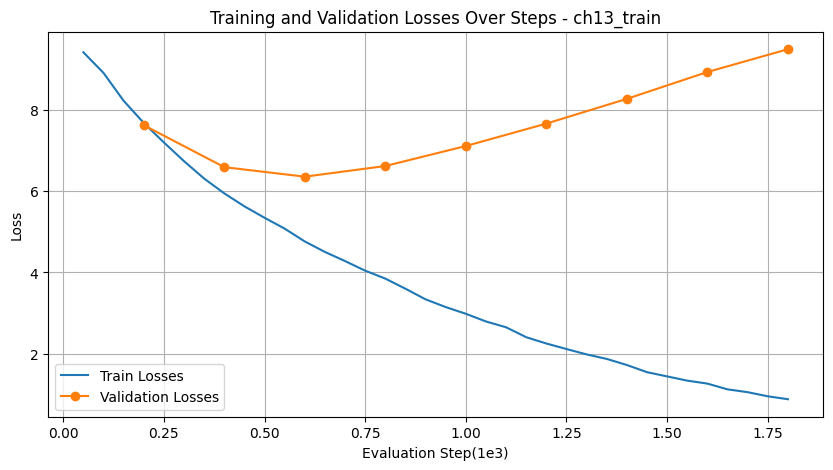

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

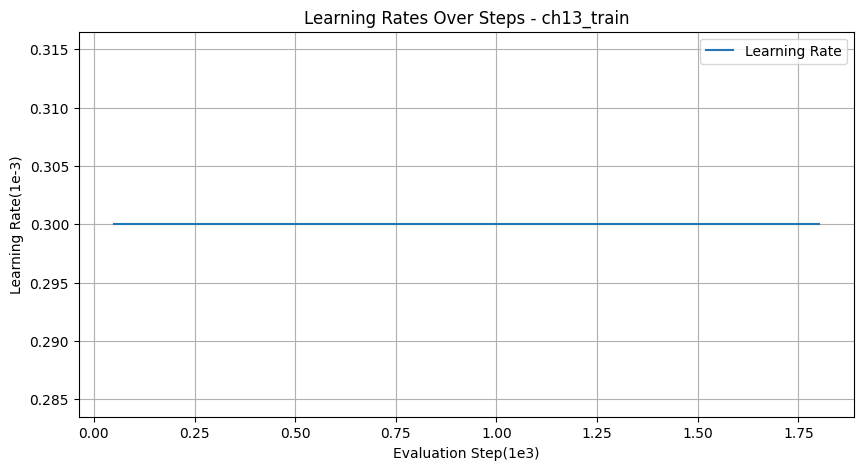

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")